# Boltzmann Machine Learning for 2Dof NVS, unsuccessful

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

## Setup Problem

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------


# Physical Constants and Parameters
M1 = 1.0
M2 = 1.0

w1 = 1.0          # Natural frequency of oscillator 1 (rad/s)
w2 = 1.0          # Natural frequency of oscillator 2 (rad/s)

wp1 = 2*(w1+0.0)  # Driving frequency for oscillator 1 (rad/s)
wp2 = 2*(w2+0.0)  # Driving frequency for oscillator 2 (rad/s)

period1 = 2*jnp.pi/w1
period2 = 2*jnp.pi/w2

Fp1 = 0.0        # Amplitude of the wp driving for oscillator 1
Fp2 = 0.00         # Amplitude of the wp driving for oscillator 2

Q1 = 100.0       # Quality factor for oscillator 1
Q2 = 100.0       # Quality factor for oscillator 2

GAMMA1 = w1/(2*Q1)
GAMMA2 = w2/(2*Q2)

gamma1 = 0.00    # Nonlinearity coefficient for oscillator 1 (Duffing term)
gamma2 = 0.00    # Nonlinearity coefficient for oscillator 2 (Duffing term)

c = .01


k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .3             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 100000# Start time
period = 2*jnp.pi/w1
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, 10000)
saveat = diffrax.SaveAt(ts=ts_dim)

y0_QP = jnp.array([0, 0, 0, 0])


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(Q1, P1, Q2, P2, args):
    dw = wp1/2 - w1  # detuning term
    
    # Parameters of the Hidden oscillator
    gamma_h, wp_h, Fp_h = args
    
    # Single oscillator terms (for both oscillators)
    H1 = 3*gamma1/(16*wp1) * (Q1**2 + P1**2)**2 + dw/2 *(Q1**2 - P1**2) + Fp1/(4*M1*wp1) * (P1**2 - Q1**2)
    H2 = 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2 + dw/2 *(Q2**2 - P2**2) + Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)

    # Coupling term
    H_coupling = c/4 * ((Q1 - Q2)**2 + (P1 - P2)**2)
    
    return H1 + H2 + H_coupling


def drift_QP_fn(t, state, args):
    """
    Drift function for the RWA equations
    """
    Q1, P1, Q2, P2 = state  # Unpack all state variables
    
    # Calculate gradients of Hamiltonian for both oscillators
    dQ1dt =  jax.grad(Hamiltonian, 1)(Q1, P1, Q2, P2, args) - GAMMA1*Q1
    dP1dt = -jax.grad(Hamiltonian, 0)(Q1, P1, Q2, P2, args) - GAMMA1*P1
    dQ2dt =  jax.grad(Hamiltonian, 3)(Q1, P1, Q2, P2, args) - GAMMA2*Q2
    dP2dt = -jax.grad(Hamiltonian, 2)(Q1, P1, Q2, P2, args) - GAMMA2*P2
    
    return jnp.array([dQ1dt, dP1dt, dQ2dt, dP2dt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations for two coupled oscillators.
    Returns a 4x4 matrix with noise terms for both oscillators.
    """
    # Noise strength for oscillator 1
    noise_strength_QP1 = jnp.sqrt(2*GAMMA1*k_B * T/(M1*w1**2))
    # Noise strength for oscillator 2  
    noise_strength_QP2 = jnp.sqrt(2*GAMMA2*k_B * T/(M2*w2**2))
    
    # Create 4x4 matrix for both oscillators [Q1, P1, Q2, P2]
    noise_matrix = jnp.zeros((4, 4))
    noise_matrix = noise_matrix.at[0:2, 0:2].set(noise_strength_QP1 * jnp.eye(2))  # First oscillator
    noise_matrix = noise_matrix.at[2:4, 2:4].set(noise_strength_QP2 * jnp.eye(2))  # Second oscillator
    return noise_matrix



In [5]:
@jax.jit
def solve_SDE_QP(args, seed=0):
    """
    Solve the SDE for the QP equations with configurable random seed
    
    Args:
        args: Parameters for the SDE
        seed (int): Random seed for noise generation (default=0)
    
    Returns:
        Array of solution samples
    """
    # Define state shape
    w_shape = (4,)  # state is (Q, P)
    
    # Create Brownian motion with specified seed
    brownian_motion_QP = diffrax.VirtualBrownianTree(
        t0, t1, 1.e-11, w_shape, jr.PRNGKey(seed), diffrax.SpaceTimeLevyArea
    )
    
    # Define terms with the new Brownian motion
    terms_QP = MultiTerm(ODETerm(drift_QP_fn), 
                        ControlTerm(diffusion_QP_fn, brownian_motion_QP))
    
    # Solve the SDE
    solution_QP = diffrax.diffeqsolve(
        terms_QP,
        solver=diffrax.SRA1(),
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0_QP,
        args=args,
        saveat=saveat,
        progress_meter=diffrax.TqdmProgressMeter(),
        max_steps=10000000000,
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
    )
    
    sde_samples_QP = solution_QP.ys
    return sde_samples_QP



### Solve to get samples from target and initial distributions (or load them from file)


In [6]:
args_0 = (0.03, wp2, 0.0)
args_target = (0.03, wp2, 0.5)
sde_samples_QP_0 = solve_SDE_QP(args_0, seed=0)
sde_samples_QP_target = solve_SDE_QP(args_target, seed=1)

# import numpy as np
# # np.save('sde_samples_QP_0.npy', np.array(sde_samples_QP_0))
# # np.save('sde_samples_QP_target.npy', np.array(sde_samples_QP_target))
# sde_samples_QP_0 = jnp.array(np.load('sde_samples_QP_0.npy'))
# sde_samples_QP_target = jnp.array(np.load('sde_samples_QP_target.npy'))


### Plot the marginals of the target and initial distributions = distributions of Q1, P1, Q2, P2

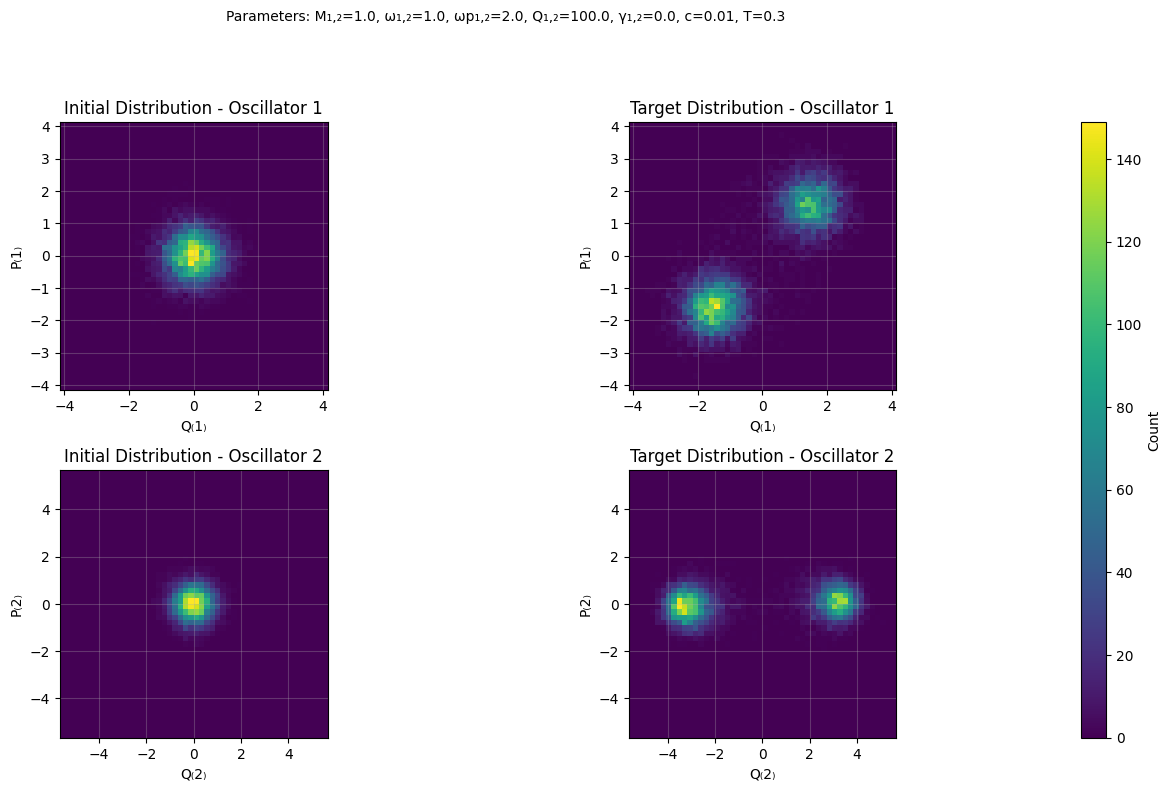

In [7]:
sample_step = 1
# Create figure with proper spacing for all plots and colorbar
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.05], wspace=0.2, hspace=0.3)

# Create subplots for both oscillators
ax1_osc1 = fig.add_subplot(gs[0, 0])  # Top left (Osc1 initial)
ax1_osc2 = fig.add_subplot(gs[1, 0])  # Bottom left (Osc2 initial)
ax2_osc1 = fig.add_subplot(gs[0, 1])  # Top right (Osc1 target)
ax2_osc2 = fig.add_subplot(gs[1, 1])  # Bottom right (Osc2 target)
cax = fig.add_subplot(gs[:, 2])        # Colorbar on right

# Get global min/max for consistent axes (for both oscillators)
all_Q1 = jnp.concatenate([sde_samples_QP_target[:, 0], sde_samples_QP_0[:, 0]])
all_P1 = jnp.concatenate([sde_samples_QP_target[:, 1], sde_samples_QP_0[:, 1]])
all_Q2 = jnp.concatenate([sde_samples_QP_target[:, 2], sde_samples_QP_0[:, 2]])
all_P2 = jnp.concatenate([sde_samples_QP_target[:, 3], sde_samples_QP_0[:, 3]])

q1_lim = max(abs(all_Q1.min()), abs(all_Q1.max()))
p1_lim = max(abs(all_P1.min()), abs(all_P1.max()))
q2_lim = max(abs(all_Q2.min()), abs(all_Q2.max()))
p2_lim = max(abs(all_P2.min()), abs(all_P2.max()))

lim1 = max(q1_lim, p1_lim) * 1.1  # Add 10% margin for oscillator 1
lim2 = max(q2_lim, p2_lim) * 1.1  # Add 10% margin for oscillator 2

# Plot distributions
bins = 50
range_lim1 = [[-lim1, lim1], [-lim1, lim1]]
range_lim2 = [[-lim2, lim2], [-lim2, lim2]]

# Initial state plots
hist1_osc1 = ax1_osc1.hist2d(sde_samples_QP_0[::sample_step, 0], 
                            sde_samples_QP_0[::sample_step, 1], 
                            bins=bins, cmap='viridis', range=range_lim1)
hist1_osc2 = ax1_osc2.hist2d(sde_samples_QP_0[::sample_step, 2], 
                            sde_samples_QP_0[::sample_step, 3], 
                            bins=bins, cmap='viridis', range=range_lim2)

# Target state plots
hist2_osc1 = ax2_osc1.hist2d(sde_samples_QP_target[::sample_step, 0], 
                            sde_samples_QP_target[::sample_step, 1], 
                            bins=bins, cmap='viridis', range=range_lim1)
hist2_osc2 = ax2_osc2.hist2d(sde_samples_QP_target[::sample_step, 2], 
                            sde_samples_QP_target[::sample_step, 3], 
                            bins=bins, cmap='viridis', range=range_lim2)

# Set properties for all axes
for ax, lim, osc_num in [(ax1_osc1, lim1, 1), (ax1_osc2, lim2, 2), 
                         (ax2_osc1, lim1, 1), (ax2_osc2, lim2, 2)]:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(f'Q₍{osc_num}₎')
    ax.set_ylabel(f'P₍{osc_num}₎')

# Titles
ax1_osc1.set_title('Initial Distribution - Oscillator 1')
ax1_osc2.set_title('Initial Distribution - Oscillator 2')
ax2_osc1.set_title('Target Distribution - Oscillator 1')
ax2_osc2.set_title('Target Distribution - Oscillator 2')

# Add colorbar
plt.colorbar(hist1_osc1[3], cax=cax, label='Count')

# Compact parameter title
title = (f'Parameters: M₁,₂={M1}, ω₁,₂={w1}, ωp₁,₂={wp1}, '
         f'Q₁,₂={Q1}, γ₁,₂={gamma1}, c={c}, T={T}')
plt.suptitle(title, y=1.02, size=10)

plt.show()

#### Compute the analytical marginals of the target distribution; assuming a Boltzmann distribution --> do not agree!!

In [1]:
import numpy as np
from scipy import integrate

# Define integration bounds
BOUND = 4  # Set integration bound to 10

# Define the Hamiltonian
def H(Q1, P1, Q2, P2):
    return Hamiltonian(Q1, P1, Q2, P2, args_target)

# Define the Boltzmann distribution
def boltzmann(Q1, P1, Q2, P2, kbT=k_B*T/4):
    return np.exp(-H(Q1, P1, Q2, P2)/kbT)

# Calculate marginal for oscillator 1 (integrating out Q2, P2)
def marginal_osc1(Q1, P1):
    def integrand(x):
        Q2, P2 = x
        return boltzmann(Q1, P1, Q2, P2)
    
    result = integrate.dblquad(lambda P2, Q2: integrand([Q2, P2]), 
                             -BOUND, BOUND,  # Q2 bounds
                             lambda x: -BOUND, lambda x: BOUND)  # P2 bounds
    return result[0]

# Calculate marginal for oscillator 2 (integrating out Q1, P1)
def marginal_osc2(Q2, P2):
    def integrand(x):
        Q1, P1 = x
        return boltzmann(Q1, P1, Q2, P2)
    
    result = integrate.dblquad(lambda P1, Q1: integrand([Q1, P1]), 
                             -BOUND, BOUND,  # Q1 bounds
                             lambda x: -BOUND, lambda x: BOUND)  # P1 bounds
    return result[0]

# Create grid for visualization (using same BOUND for consistency)
q = np.linspace(-BOUND, BOUND, 50)
p = np.linspace(-BOUND, BOUND, 50)
Q, P = np.meshgrid(q, p)

# Calculate marginal distributions
marginal1 = np.zeros_like(Q)
marginal2 = np.zeros_like(Q)

for i in range(len(q)):
    for j in range(len(p)):
        marginal1[i,j] = marginal_osc1(Q[i,j], P[i,j])
        marginal2[i,j] = marginal_osc2(Q[i,j], P[i,j])

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(marginal1, extent=[-BOUND, BOUND, -BOUND, BOUND], origin='lower', aspect='equal')
ax1.set_title('Marginal Distribution - Oscillator 1')
ax1.set_xlabel('Q₁')
ax1.set_ylabel('P₁')

im2 = ax2.imshow(marginal2, extent=[-BOUND, BOUND, -BOUND, BOUND], origin='lower', aspect='equal')
ax2.set_title('Marginal Distribution - Oscillator 2')
ax2.set_xlabel('Q₂')
ax2.set_ylabel('P₂')

plt.colorbar(im1, ax=ax1, label='Probability density')
plt.colorbar(im2, ax=ax2, label='Probability density')

plt.tight_layout()
plt.show()

NameError: name 'k_B' is not defined

#### Compute the numerical differentiation gradients of the target distribution using Maximum Likelihood

In [14]:
def estimate_gradients_ML(args_in, target_samples, epsilon=1e-4):
    """
    Estimate gradients using Maximum Likelihood on the Boltzmann distribution
    by evaluating Hamiltonian at target points
    
    Args:
        args: (gamma_h, wp_h, Fp_h) - current parameters
        target_samples: samples from target distribution
        epsilon: small perturbation for finite difference
    """
    gamma_h, wp_h, Fp_h = args_in
    kT = k_B * T  # thermal energy
    
    # Evaluate Hamiltonian at target points for current parameters
    def compute_avg_energy(params):
        gamma, wp, Fp = params
        energies = jax.vmap(lambda sample: Hamiltonian(
            sample[0], sample[1], sample[2], sample[3], 
            (gamma, wp, Fp)
        ))(target_samples)
        return jnp.mean(energies)
    
    # Current energy
    E_current = compute_avg_energy(args_in)
    
    # Perturbed energies for finite differences
    args_gamma_plus = (gamma_h + epsilon, wp_h, Fp_h)
    E_gamma_plus = compute_avg_energy(args_gamma_plus)
    
    args_Fp_plus = (gamma_h, wp_h, Fp_h + epsilon)
    E_Fp_plus = compute_avg_energy(args_Fp_plus)
    
    # Compute gradients using finite differences
    # For Maximum Likelihood, we want to minimize <E>/kT
    grad_gamma = (E_gamma_plus - E_current) / (epsilon * kT)
    grad_Fp = (E_Fp_plus - E_current) / (epsilon * kT)
    
    return grad_gamma, grad_Fp


In [24]:
estimate_gradients_ML((10,10,10), sde_samples_QP_target, epsilon=1e-5)


(Array(7.30203923, dtype=float64), Array(-0.79833737, dtype=float64))

## Set up the clamped problem

In [8]:
def Hamiltonian_clamped(Q2, P2, Q1_fixed, P1_fixed, args):
    dw = wp1/2 - w1
    gamma_h, wp_h, Fp_h = args
    
    H2 = 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2 + dw/2 *(Q2**2 - P2**2) + Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)
    H_coupling = c/4 * ((Q1_fixed - Q2)**2 + (P1_fixed - P2)**2)
    
    return H2 + H_coupling

def drift_QP_clamped(t, state, Q1_fixed, P1_fixed, args):
    Q2, P2 = state  # Now state only contains Q2 and P2
    
    dQ2dt = jax.grad(Hamiltonian_clamped, 1)(Q2, P2, Q1_fixed, P1_fixed, args) - GAMMA2*Q2
    dP2dt = -jax.grad(Hamiltonian_clamped, 0)(Q2, P2, Q1_fixed, P1_fixed, args) - GAMMA2*P2
    
    return jnp.array([dQ2dt, dP2dt])

@jax.jit
def solve_SDE_QP_clamped(Q1_fixed, P1_fixed, args, seed=0):
    """
    Solve the SDE for the QP equations with clamped Q1 and P1 values
    """
    # Define new terms for clamped system (2D instead of 4D)
    w_shape_clamped = (2,)  # state is now just (Q2, P2)
    brownian_motion_QP_clamped = diffrax.VirtualBrownianTree(
        t0, t1, 1.e-11, w_shape_clamped, jr.PRNGKey(seed), diffrax.SpaceTimeLevyArea
    )
    
    # Create partial function with fixed Q1, P1
    drift_fn = lambda t, state, args: drift_QP_clamped(t, state, Q1_fixed, P1_fixed, args)
    
    terms_QP_clamped = MultiTerm(
        ODETerm(drift_fn), 
        ControlTerm(lambda t, state, args: diffusion_QP_fn(t, state, args)[2:4, 2:4], brownian_motion_QP_clamped)
    )
    
    y0_QP_clamped = jnp.array([0, 0])  # Initial conditions for Q2, P2 only
    
    solution_QP = diffrax.diffeqsolve(
        terms_QP_clamped,
        solver=diffrax.SRA1(),
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0_QP_clamped,
        args=args,
        saveat=saveat,
        progress_meter=diffrax.TqdmProgressMeter(),
        max_steps=10000000000,
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
    )
    
    sde_samples_QP = solution_QP.ys
    return sde_samples_QP

In [22]:
downsample_step = 500

# Downsample the Q1,P1 values from the zero simulation, starting halfway through
halfway_idx = len(sde_samples_QP_target) // 2  # Get the midpoint index
Q1_samples_target = sde_samples_QP_target[::downsample_step, 0]
P1_samples_target = sde_samples_QP_target[::downsample_step, 1]

##### Plot the samples used for clamping

In [ ]:

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Calculate appropriate limits for the plot
q1_lim = max(abs(Q1_samples_target.min()), abs(Q1_samples_target.max()))
p1_lim = max(abs(P1_samples_target.min()), abs(P1_samples_target.max()))
lim = max(q1_lim, p1_lim) * 1.1  # Add 10% margin

# Create 2D histogram
hist = ax.hist2d(Q1_samples_target, P1_samples_target, 
                 bins=50, 
                 cmap='viridis',
                 range=[[-lim, lim], [-lim, lim]])

# Add colorbar
plt.colorbar(hist[3], ax=ax, label='Count')

# Set plot properties
ax.set_aspect('equal')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Q₁')
ax.set_ylabel('P₁')
ax.set_title('Downsampled Target Distribution\n' + 
             f'(every {downsample_step}th point)')

plt.tight_layout()
plt.show()


##### Solve the clamped problem

In [ ]:

# Create pairs of Q1,P1 values
Q1P1_pairs_target = jnp.stack([Q1_samples_target, P1_samples_target], axis=1)  # Shape: (n_samples, 2)

# Vectorize the clamped solver over Q1,P1 pairs

def batch_solve_clamped(Q1P1_pair, args, seed):
    return solve_SDE_QP_clamped(Q1P1_pair[0], Q1P1_pair[1], args, seed)

# Run the parallel simulation
# Use in_axes to specify which arguments should be mapped over
seeds = jnp.arange(len(Q1P1_pairs_target))
clamped_samples = jax.vmap(batch_solve_clamped, in_axes=(0, None, 0))(Q1P1_pairs_target, args_0, seeds)

##### Plot the clamped trajectories

In [ ]:
# Create a single square figure
fig, ax = plt.subplots(figsize=(8, 8))

# Number of trajectories to plot
n_trajectories = min(1, clamped_samples.shape[0])

# Calculate halfway point
halfway_idx = clamped_samples.shape[1] // 2

# Plot phase space trajectories (only second half)
for i in range(n_trajectories):
    ax.plot(clamped_samples[i, halfway_idx:, 0], 
            clamped_samples[i, halfway_idx:, 1], 
            label=f'Q1,P1 pair {i}', alpha=0.7)
    
ax.set_xlabel('Q₂')
ax.set_ylabel('P₂')
ax.set_title('Phase Space Trajectories (Clamped) - Second Half')
ax.legend()
ax.grid(True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left subplot: Heat map of clamped trajectories
# Combine all trajectories into a single array for histogram
all_Q2 = clamped_samples[:, halfway_idx:, 0].flatten()
all_P2 = clamped_samples[:, halfway_idx:, 1].flatten()

# Calculate appropriate limits
q2_lim = max(abs(all_Q2.min()), abs(all_Q2.max()))
p2_lim = max(abs(all_P2.min()), abs(all_P2.max()))
lim = max(q2_lim, p2_lim) * 1.1

# Create 2D histogram for clamped trajectories
hist1 = ax1.hist2d(all_Q2, all_P2, 
                   bins=50, 
                   cmap='viridis',
                   range=[[-lim, lim], [-lim, lim]])

# Right subplot: Heat map of unclamped trajectories
hist2 = ax2.hist2d(sde_samples_QP_0[halfway_idx:, 2], 
                   sde_samples_QP_0[halfway_idx:, 3], 
                   bins=50,
                   cmap='viridis',
                   range=[[-lim, lim], [-lim, lim]])

# Add colorbars
plt.colorbar(hist1[3], ax=ax1, label='Count')
plt.colorbar(hist2[3], ax=ax2, label='Count')

# Set properties for both plots
for ax in [ax1, ax2]:
    ax.set_xlabel('Q₂')
    ax.set_ylabel('P₂')
    ax.grid(True)
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

ax1.set_title('Clamped Trajectories')
ax2.set_title('Unclamped Trajectory')

plt.tight_layout()
plt.show()

## Setup BM training

In [24]:
def dH_dgamma_h(Q2, P2, args):
    """Partial derivative of Hamiltonian with respect to gamma_h"""
    gamma_h, wp_h, Fp_h = args
    
    # Only H2 term depends on gamma_h
    # From: 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2
    return 3/(16*wp_h) * (Q2**2 + P2**2)**2

def dH_dFp_h(Q2, P2, args):
    """Partial derivative of Hamiltonian with respect to Fp_h"""
    gamma_h, wp_h, Fp_h = args
    
    # Only H2 term depends on Fp_h
    # From: Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)
    return 1/(4*M2*wp_h) * (P2**2 - Q2**2)
def compute_gradients(sde_samples_free, sde_samples_clamped, args):
    """
    Compute gradients using Boltzmann machine training approach.
    
    Args:
        sde_samples_free: samples from free running simulation (Q1,P1,Q2,P2)
        sde_samples_clamped: samples from clamped simulation (Q2,P2)
        args: (gamma_h, wp_h, Fp_h)
    
    Returns:
        gradients for gamma_h and Fp_h
    """
    # Compute average gradient for free running case
    dH_dgamma_free = jnp.mean(jax.vmap(
        lambda sample: dH_dgamma_h(sample[2], sample[3], args)
    )(sde_samples_free))
    
    dH_dFp_free = jnp.mean(jax.vmap(
        lambda sample: dH_dFp_h(sample[2], sample[3], args)
    )(sde_samples_free))
    
    dH_dgamma_clamped = jnp.mean(jax.vmap(
        lambda sample: dH_dgamma_h(sample[0], sample[1], args)
    )(sde_samples_clamped))
    
    dH_dFp_clamped = jnp.mean(jax.vmap(
        lambda sample: dH_dFp_h(sample[0], sample[1], args)
    )(sde_samples_clamped))
    
    # Compute gradient as difference between free and clamped averages
    grad_gamma = dH_dgamma_free - dH_dgamma_clamped
    grad_Fp = dH_dFp_free - dH_dFp_clamped
    
    # print(f"dH_dgamma_free: {dH_dgamma_free:.4f}, dH_dgamma_clamped: {dH_dgamma_clamped:.4f}")
    # print(f"dH_dFp_free: {dH_dFp_free:.4f}, dH_dFp_clamped: {dH_dFp_clamped:.4f}")
    
    return grad_gamma, grad_Fp

#### Compute a single gradient form the above clamped and free solutions

In [ ]:
# Calculate gradients using the data from the previous plots
grad_gamma_per_clamping, grad_Fp_per_clamping = jax.vmap(compute_gradients, in_axes=(None, 0, None))(
    sde_samples_QP_0[halfway_idx:], 
    clamped_samples[:,halfway_idx:],  
    args_0
)

# Average gradients across all clamped trajectories
grad_gamma = jnp.mean(grad_gamma_per_clamping)
grad_Fp = jnp.mean(grad_Fp_per_clamping)

print("\nFinal averaged gradients:")
print(f"grad_gamma = {grad_gamma:.4f}")
print(f"grad_Fp = {grad_Fp:.4f}")

### Full BM training loop

Setup the training loop

In [12]:
# Training loop
def train_step(args, learning_rate=0.01):
    """
    Perform one training step
    """
    # Get samples from current parameters
    sde_samples_free = solve_SDE_QP(args)
    clamped_samples = jax.vmap(batch_solve_clamped, in_axes=(0, None))(Q1P1_pairs_target, args)
    
    halfway_idx = len(sde_samples_QP_target) // 2

    grad_gamma_per_clamping, grad_Fp_per_clamping = jax.vmap(compute_gradients, in_axes=(None, 0, None))(
        sde_samples_free[halfway_idx:], 
        clamped_samples[:,halfway_idx:],  
        args
    )
    # Sum up the gradients across all clamped samples
    grad_gamma = jnp.mean(grad_gamma_per_clamping)  # or jnp.sum(grad_gamma)
    grad_Fp = jnp.mean(grad_Fp_per_clamping)        # or jnp.sum(grad_Fp)
    
    print(f"Gradients: gamma_h = {grad_gamma:.4f}, Fp_h = {grad_Fp:.4f}")
    # Update parameters
    gamma_h, wp_h, Fp_h = args
    new_gamma_h = gamma_h - learning_rate * grad_gamma
    new_Fp_h = Fp_h - learning_rate * grad_Fp
    
    return (new_gamma_h, wp_h, new_Fp_h)

def train(initial_args, n_steps=100, learning_rate=0.01):
    args = initial_args
    # Store history of parameters
    history = {
        'gamma_h': [initial_args[0]],
        'Fp_h': [initial_args[2]],
        'step': [0]
    }
    
    for step in range(n_steps):
        args = train_step(args, learning_rate)
        # Store parameters
        history['gamma_h'].append(args[0])
        history['Fp_h'].append(args[2])
        history['step'].append(step + 1)
        
        if step % 1 == 0:
            print(f"Step {step}: gamma_h = {args[0]:.4f}, Fp_h = {args[2]:.4f}")
    
    # Plot the training history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history['step'], history['gamma_h'], '-o')
    ax1.axhline(y=args_target[0], color='r', linestyle='--', label='Target γ')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('γ_h')
    ax1.grid(True)
    ax1.legend()
    
    ax2.plot(history['step'], history['Fp_h'], '-o')
    ax2.axhline(y=args_target[2], color='r', linestyle='--', label='Target Fp')
    ax2.set_xlabel('Step')
    ax2.set_ylabel('Fp_h')
    ax2.grid(True)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return args, history

Run the training loop

In [ ]:
# Starting from args_0 and training towards args_target
initial_args = args_0  # (gamma2, wp2, Fp2)
# initial_args =  (0.03, wp2, 0.3)
final_args = train(initial_args, n_steps=5, learning_rate=0.01)

##### Plot the final distribution and compare to target and initial distribution

In [ ]:
# Run simulation with final args
sde_samples_QP_final = solve_SDE_QP(final_args[0])

# Create figure with proper spacing for three plots and colorbar
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.2)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
cax = fig.add_subplot(gs[3])

# Get global min/max for consistent axes
all_Q = jnp.concatenate([
    sde_samples_QP_target[:, 0], 
    sde_samples_QP_0[:, 0],
    sde_samples_QP_final[:, 0]
])
all_P = jnp.concatenate([
    sde_samples_QP_target[:, 1], 
    sde_samples_QP_0[:, 1],
    sde_samples_QP_final[:, 1]
])
q_lim = max(abs(all_Q.min()), abs(all_Q.max()))
p_lim = max(abs(all_P.min()), abs(all_P.max()))
lim = max(q_lim, p_lim) * 1.1

# Plot distributions
bins = 50
range_lim = [[-lim, lim], [-lim, lim]]
hist1 = ax1.hist2d(sde_samples_QP_0[::sample_step, 0], 
                   sde_samples_QP_0[::sample_step, 1], 
                   bins=bins, cmap='viridis', range=range_lim)
hist2 = ax2.hist2d(sde_samples_QP_target[::sample_step, 0], 
                   sde_samples_QP_target[::sample_step, 1], 
                   bins=bins, cmap='viridis', range=range_lim)
hist3 = ax3.hist2d(sde_samples_QP_final[::sample_step, 0], 
                   sde_samples_QP_final[::sample_step, 1], 
                   bins=bins, cmap='viridis', range=range_lim)

# Set identical axes properties
for ax in [ax1, ax2, ax3]:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Q₁')
    ax.set_ylabel('P₁')

# Titles
ax1.set_title('Initial Distribution\n' + f'γ={args_0[0]:.3f}, Fp={args_0[2]:.3f}')
ax2.set_title('Target Distribution\n' + f'γ={args_target[0]:.3f}, Fp={args_target[2]:.3f}')
ax3.set_title('Final Distribution\n' + f'γ={final_args[0][0]:.3f}, Fp={final_args[0][2]:.3f}')

# Add colorbar
plt.colorbar(hist1[3], cax=cax, label='Count')

# Compact parameter title
title = (f'Parameters: M₁,₂={M1}, ω₁,₂={w1}, ωp₁,₂={wp1}, '
         f'Q₁,₂={Q1}, γ₁,₂={gamma1}, c={c}, T={T}')
plt.suptitle(title, y=1.02, size=10)

plt.show()